# 04 — Filter bank: Low/High/Band/BandStop

Each filter is an `nn.Module` wrapping an FIR kernel registered as
a buffer. Push an impulse through each; the FFT magnitude of the
output is the response.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

import scitex_nn

fs, seq_len = 500, 1024
cutoff = 20.0
band = (8.0, 30.0)

impulse = torch.zeros(1, 1, seq_len)
impulse[0, 0, seq_len // 2] = 1.0
freqs = np.fft.rfftfreq(seq_len, d=1.0 / fs)

## Build the four filters

In [2]:
bands = torch.tensor([list(band)], dtype=torch.float32)
filters = {
    f"LowPass <{cutoff:.0f} Hz": scitex_nn.LowPassFilter(cutoff, fs, seq_len),
    f"HighPass >{cutoff:.0f} Hz": scitex_nn.HighPassFilter(cutoff, fs, seq_len),
    f"BandPass {band[0]:.0f}-{band[1]:.0f} Hz": scitex_nn.BandPassFilter(
        bands, fs, seq_len
    ),
    f"BandStop {band[0]:.0f}-{band[1]:.0f} Hz": scitex_nn.BandStopFilter(
        bands, fs, seq_len
    ),
}

## Frequency response (magnitude, normalised)

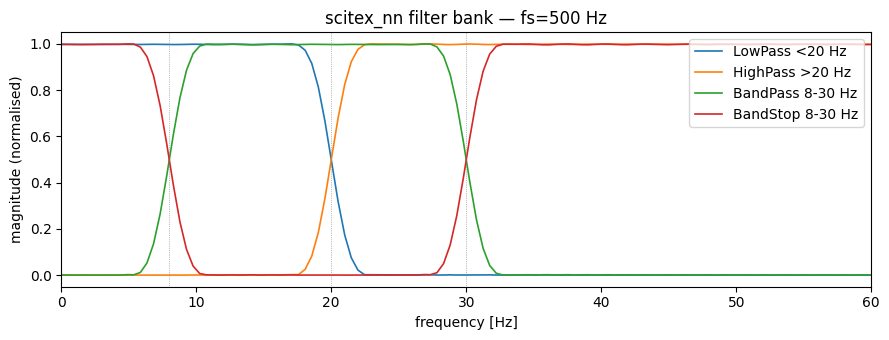

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for name, filt in filters.items():
    y = filt(impulse).detach().numpy().reshape(-1)[:seq_len]
    mag = np.abs(np.fft.rfft(y))
    ax.plot(freqs, mag / mag.max(), lw=1.2, label=name)
for v in (cutoff, *band):
    ax.axvline(v, color="grey", ls=":", lw=0.5)
ax.set_xlim(0, 60)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("magnitude (normalised)")
ax.set_title(f"scitex_nn filter bank — fs={fs} Hz")
fig.tight_layout()
plt.show()